# Start here: Reading sensitivity landscapes

This notebook is a **teaching-first guide** for the sensitivity layer in the Cantera Equilibrium Accessibility workflow.

It reads the committed alanine MVP outputs from:

```text
studies/alanine_mvp/
```

It does **not** run Cantera, build YAML mechanisms, extract CHNOSZ data, or refit thermochemistry. A newcomer should be able to **Run All** and learn how to interpret the sensitivity outputs even without Cantera installed.

By the end, you should understand:

- what a sensitivity landscape answers,
- how the inventory-grid and ΔG-sweep plots should be read,
- what `accessible`, `trace`, `significant`, and `below_threshold` mean,
- how the bundled alanine MVP supports a robustness verdict,
- and where to go next if you want to run your own study.


## 1 — What this notebook answers

The original equilibrium-accessibility workflow answers a single-scenario question:

> Given one starting inventory and one thermochemical dataset, does a target product become equilibrium-accessible?

The v2 sensitivity layer asks a stronger question:

> Does that accessibility call survive changes in starting inventory and target Gibbs free energy?

That distinction matters. A single equilibrium run can say that a product crosses a threshold under one modeled condition. A sensitivity landscape can show whether that call is robust across a region of model space, or whether it only appears under a narrow set of assumptions.

This notebook uses **alanine** as the worked example because the repository ships with an already-computed alanine MVP. The teaching goal is not to prove anything new about alanine; it is to show how the workflow’s outputs should be interpreted.

The most important caveat is this:

> **Equilibrium-accessible does not mean kinetically fast, experimentally abundant, or guaranteed to form.**

It means the target crosses a configured equilibrium mole-fraction threshold under the modeled assumptions.


## 2 — From one equilibrium answer to a landscape

A useful way to think about v1 versus v2 is:

| Workflow level | Object | Question |
|---|---|---|
| Single equilibrium case | One point | Is the target accessible here? |
| Inventory landscape | A grid of points | Where in starting-inventory space is the target accessible? |
| ΔG sweep | A line of points | Does the result depend delicately on the target Gibbs energy? |
| NH3 × ΔG landscape | A two-dimensional map | Does energetic sensitivity depend on feedstock availability? |

Each point in a sensitivity landscape is still an ordinary Cantera equilibrium calculation. The difference is that the workflow generates many related cases, keeps the design variables attached to every result, and writes tidy tables that can be summarized, plotted, or used downstream.

For the alanine MVP, the committed study contains three substudies:

1. **`inventory_landscape`** — varies NH3 and the C2H2/HCN ratio.
2. **`deltaG_sweep`** — shifts alanine’s Gibbs free energy while holding inventory fixed.
3. **`nh3_deltaG_landscape`** — varies NH3 availability and alanine ΔG offset together.


## 3 — Vocabulary for interpreting the outputs

The workflow uses threshold-based language. These words are meant to prevent overclaiming.

| Term | Meaning |
|---|---|
| `X_eq` | Equilibrium mole fraction of the target species. |
| `n_eq_mol` | Reconstructed equilibrium moles of the target species. |
| `formation_X_threshold` | Mole-fraction cutoff for calling a target formed/accessible. The bundled alanine MVP uses `1e-12`. |
| `significant_X_threshold` | Higher mole-fraction cutoff for calling a target `significant`. The bundled alanine MVP uses `1e-6`. |
| `below_threshold` | Target does not reach the configured formation/accessibility threshold. |
| `trace` | Target reaches the formation threshold but remains below the significant threshold. |
| `significant` | Target reaches the higher significant threshold. |
| `formed_bool` | Boolean accessibility flag based on the configured thresholds and solver status. |
| `robust accessible` | The target remains accessible across the relevant tested sweep space. |
| `inventory-gated` | Accessibility depends strongly on starting inventory. |
| `energetically fragile` | Accessibility changes when the target Gibbs free energy is shifted. |

In the figures, the thresholded view answers the accessibility question. The autoscaled view helps reveal gradients within the accessible or below-threshold regions.

A common mistake is to treat the color scale as a yield prediction. It is safer to read the plot as a map of equilibrium abundance **within the model**, not as an experimental yield forecast.


## 4 — Load the committed alanine MVP outputs

This section loads only existing files. If these files are present, the notebook can run without Cantera.

The important files are:

```text
studies/alanine_mvp/design_matrix.csv
studies/alanine_mvp/run_manifest.csv
studies/alanine_mvp/model_manifest.csv
studies/alanine_mvp/thermo_offsets.csv
studies/alanine_mvp/results/sensitivity_case_summary.csv
studies/alanine_mvp/results/sensitivity_landscape_grid.csv
studies/alanine_mvp/results/sensitivity_run_summary.md
studies/alanine_mvp/results/SCHEMA.md
```

The design files describe what was planned. The result files describe what happened after the equilibrium calculations were run.


In [1]:
from __future__ import annotations

from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display


def find_project_root(start: Path | None = None) -> Path:
    """Find the repository root whether the notebook runs from repo root or notebooks/."""
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "studies" / "alanine_mvp").exists() and (candidate / "notebooks").exists():
            return candidate
    # Fallback for the common case of launching Jupyter from the notebooks folder.
    if start.name == "notebooks":
        return start.parent
    return start


PROJECT_ROOT = find_project_root()
STUDY_DIR = PROJECT_ROOT / "studies" / "alanine_mvp"
RESULTS_DIR = STUDY_DIR / "results"
FIGURES_DIR = STUDY_DIR / "figures"

print(f"Project root: {PROJECT_ROOT}")
print(f"Study directory: {STUDY_DIR}")

required_files = [
    STUDY_DIR / "design_matrix.csv",
    STUDY_DIR / "run_manifest.csv",
    STUDY_DIR / "model_manifest.csv",
    STUDY_DIR / "thermo_offsets.csv",
    RESULTS_DIR / "sensitivity_case_summary.csv",
    RESULTS_DIR / "sensitivity_landscape_grid.csv",
    RESULTS_DIR / "sensitivity_run_summary.md",
]

missing = [path for path in required_files if not path.exists()]
if missing:
    raise FileNotFoundError(
        "This teaching notebook expects the committed alanine_mvp outputs.\n"
        "Missing files:\n" + "\n".join(str(path) for path in missing)
    )

# Core tables.
design = pd.read_csv(STUDY_DIR / "design_matrix.csv")
run_manifest = pd.read_csv(STUDY_DIR / "run_manifest.csv")
model_manifest = pd.read_csv(STUDY_DIR / "model_manifest.csv")
thermo_offsets = pd.read_csv(STUDY_DIR / "thermo_offsets.csv")
case_summary = pd.read_csv(RESULTS_DIR / "sensitivity_case_summary.csv")
landscape = pd.read_csv(RESULTS_DIR / "sensitivity_landscape_grid.csv")

print("Loaded alanine MVP outputs.")
print(f"Design cases: {len(design):,}")
print(f"Run-manifest rows: {len(run_manifest):,}")
print(f"Case summaries: {len(case_summary):,}")
print(f"Landscape rows: {len(landscape):,}")
print(f"Model variants: {len(model_manifest):,}")
print(f"Thermo offsets: {len(thermo_offsets):,}")


Project root: .
Study directory: studies/alanine_mvp
Loaded alanine MVP outputs.
Design cases: 911
Run-manifest rows: 911
Case summaries: 911
Landscape rows: 911
Model variants: 12
Thermo offsets: 11


The key join field is `case_id`. A single case appears in the design matrix, run manifest, and summary outputs with the same identifier.

The `substudy_id` column tells you which sweep a case belongs to. That is the first column to check whenever you want to interpret the outputs by experiment type rather than as one large table.


In [2]:
substudy_counts = (
    design["substudy_id"]
    .value_counts()
    .rename_axis("substudy_id")
    .reset_index(name="planned_cases")
    .sort_values("substudy_id")
)

display(substudy_counts)


,substudy_id,planned_cases
2,deltaG_sweep,11
0,inventory_landscape,625
1,nh3_deltaG_landscape,275


## 5 — The design matrix: what was varied?

The design matrix is the study’s recipe book. Each row is one planned equilibrium calculation.

For alanine, the design variables include:

- `NH3_mol` — initial ammonia amount,
- `HCN_mol` — initial HCN amount,
- `C2H2_mol` — initial acetylene amount,
- `C2H2_over_HCN` — acetylene-to-HCN ratio,
- `deltaG_offset_kJ_mol` — exact Gibbs free-energy shift applied to alanine variants,
- `T_C` and `P_Pa` — physical conditions.

The inventory landscape changes starting inventory. The ΔG sweep changes target thermochemistry. The NH3 × ΔG landscape combines both ideas.


In [3]:
preview_cols = [
    "case_id",
    "substudy_id",
    "target_product",
    "target_variant",
    "NH3_mol",
    "HCN_mol",
    "C2H2_mol",
    "C2H2_over_HCN",
    "deltaG_offset_kJ_mol",
    "T_C",
    "model_id",
]
preview_cols = [col for col in preview_cols if col in design.columns]

display(design[preview_cols].head(12))


,case_id,substudy_id,target_product,target_variant,NH3_mol,HCN_mol,C2H2_mol,C2H2_over_HCN,deltaG_offset_kJ_mol,T_C,model_id
0,ALA_INV_000001,inventory_landscape,Alanine(aq),Alanine(aq),0.0,0.02,0.000000,0.000000,0.0,0.0,M_bcd9cb2f0c3e
1,ALA_INV_000002,inventory_landscape,Alanine(aq),Alanine(aq),0.0,0.02,0.004167,0.208333,0.0,0.0,M_bcd9cb2f0c3e
2,ALA_INV_000003,inventory_landscape,Alanine(aq),Alanine(aq),0.0,0.02,0.008333,0.416667,0.0,0.0,M_bcd9cb2f0c3e
3,ALA_INV_000004,inventory_landscape,Alanine(aq),Alanine(aq),0.0,0.02,0.012500,0.625000,0.0,0.0,M_bcd9cb2f0c3e
4,ALA_INV_000005,inventory_landscape,Alanine(aq),Alanine(aq),0.0,0.02,0.016667,0.833333,0.0,0.0,M_bcd9cb2f0c3e
5,ALA_INV_000006,inventory_landscape,Alanine(aq),Alanine(aq),0.0,0.02,0.020833,1.041667,0.0,0.0,M_bcd9cb2f0c3e
6,ALA_INV_000007,inventory_landscape,Alanine(aq),Alanine(aq),0.0,0.02,0.025000,1.250000,0.0,0.0,M_bcd9cb2f0c3e
7,ALA_INV_000008,inventory_landscape,Alanine(aq),Alanine(aq),0.0,0.02,0.029167,1.458333,0.0,0.0,M_bcd9cb2f0c3e
8,ALA_INV_000009,inventory_landscape,Alanine(aq),Alanine(aq),0.0,0.02,0.033333,1.666667,0.0,0.0,M_bcd9cb2f0c3e
9,ALA_INV_000010,inventory_landscape,Alanine(aq),Alanine(aq),0.0,0.02,0.037500,1.875000,0.0,0.0,M_bcd9cb2f0c3e


In [4]:
# Compact range summary for the main numerical design variables.
design_vars = [
    "NH3_mol",
    "HCN_mol",
    "C2H2_mol",
    "C2H2_over_HCN",
    "deltaG_offset_kJ_mol",
    "T_C",
    "P_Pa",
]
design_vars = [col for col in design_vars if col in design.columns]

ranges = (
    design.groupby("substudy_id")[design_vars]
    .agg(["min", "max", "nunique"])
)

display(ranges)


NH3_mol               HCN_mol               C2H2_mol  \
                         min   max nunique     min   max nunique      min   
substudy_id                                                                 
deltaG_sweep            0.05  0.05       1    0.02  0.02       1    0.042   
inventory_landscape     0.00  0.15      25    0.02  0.02       1    0.000   
nh3_deltaG_landscape    0.00  0.15      25    0.02  0.02       1    0.042   

                                    C2H2_over_HCN  ...          \
                        max nunique           min  ... nunique   
substudy_id                                        ...           
deltaG_sweep          0.042       1           2.1  ...       1   
inventory_landscape   0.100      25           0.0  ...      25   
nh3_deltaG_landscape  0.042       1           2.1  ...       1   

                     deltaG_offset_kJ_mol                 T_C               \
                                      min    max nunique  min  max nunique   
substudy_id                                                                  
deltaG_sweep                       -200.0  200.0      11  0.0  0.0       1   
inventory_landscape                   0.0    0.0       1  0.0  0.0       1   
nh3_deltaG_landscape               -200.0  200.0      11  0.0  0.0       1   

                          P_Pa                    
                           min       max nunique  
substudy_id                                       
deltaG_sweep          101325.0  101325.0       1  
inventory_landscape   101325.0  101325.0       1  
nh3_deltaG_landscape  101325.0  101325.0       1  

[3 rows x 21 columns]

How to read this range table:

- `inventory_landscape` should show many unique NH3 values and many unique C2H2/HCN values, with ΔG fixed at zero.
- `deltaG_sweep` should show many unique ΔG offsets, with inventory fixed.
- `nh3_deltaG_landscape` should show many unique NH3 values and many unique ΔG offsets, with HCN and C2H2 fixed.

This is the first sanity check for any sensitivity study: before interpreting the result, confirm that the intended variables actually changed.


## 6 — Reading the case summary table

The case summary is the main machine-readable result table. It has one row per case and keeps the design variables attached to the target outcome.

Important columns:

| Column | Why it matters |
|---|---|
| `case_id` | Stable identifier for the equilibrium case. |
| `substudy_id` | Which sweep the case belongs to. |
| `target_variant` | Base target or ΔG-shifted variant. |
| `X_eq` | Target equilibrium mole fraction. |
| `log10_X_eq` | Log-scaled target mole fraction for plotting. |
| `n_eq_mol` | Reconstructed target moles. |
| `formed_bool` | Threshold-based accessibility flag. |
| `formation_call` | Human-readable call such as `significant`, `trace`, or `below_threshold`. |
| `solver_status` | Whether the solver completed successfully. |
| `suspect_balance` | Whether element-balance spread exceeded the configured tolerance. |

When auditing a study, first check solver success and balance flags. Then interpret `X_eq`, `formed_bool`, and `formation_call`.


In [5]:
summary_cols = [
    "case_id",
    "substudy_id",
    "target_variant",
    "NH3_mol",
    "C2H2_over_HCN",
    "deltaG_offset_kJ_mol",
    "X_eq",
    "log10_X_eq",
    "n_eq_mol",
    "formed_bool",
    "formation_call",
    "solver_status",
    "suspect_balance",
]
summary_cols = [col for col in summary_cols if col in case_summary.columns]

display(case_summary[summary_cols].head(15))


,case_id,substudy_id,target_variant,NH3_mol,C2H2_over_HCN,deltaG_offset_kJ_mol,X_eq,log10_X_eq,n_eq_mol,formed_bool,formation_call,solver_status,suspect_balance
0,ALA_DG_000001,deltaG_sweep,Alanine__dG_m200(aq),0.05,2.100000,-200.0,0.019011,-1.720986,0.020000,True,significant,ok,False
1,ALA_DG_000002,deltaG_sweep,Alanine__dG_m160(aq),0.05,2.100000,-160.0,0.019011,-1.720986,0.020000,True,significant,ok,False
2,ALA_DG_000003,deltaG_sweep,Alanine__dG_m120(aq),0.05,2.100000,-120.0,0.019011,-1.720986,0.020000,True,significant,ok,False
3,ALA_DG_000004,deltaG_sweep,Alanine__dG_m080(aq),0.05,2.100000,-80.0,0.019011,-1.720986,0.020000,True,significant,ok,False
4,ALA_DG_000005,deltaG_sweep,Alanine__dG_m040(aq),0.05,2.100000,-40.0,0.019011,-1.720986,0.020000,True,significant,ok,False
5,ALA_DG_000006,deltaG_sweep,Alanine__dG_000(aq),0.05,2.100000,0.0,0.019011,-1.720986,0.020000,True,significant,ok,False
6,ALA_DG_000007,deltaG_sweep,Alanine__dG_p040(aq),0.05,2.100000,40.0,0.019011,-1.720986,0.020000,True,significant,ok,False
7,ALA_DG_000008,deltaG_sweep,Alanine__dG_p080(aq),0.05,2.100000,80.0,0.019011,-1.720986,0.020000,True,significant,ok,False
8,ALA_DG_000009,deltaG_sweep,Alanine__dG_p120(aq),0.05,2.100000,120.0,0.019011,-1.720986,0.020000,True,significant,ok,False
9,ALA_DG_000010,deltaG_sweep,Alanine__dG_p160(aq),0.05,2.100000,160.0,0.019011,-1.720986,0.020000,True,significant,ok,False


In [6]:
# Audit and interpretation summary by substudy.
audit_summary = (
    case_summary
    .groupby("substudy_id")
    .agg(
        cases=("case_id", "count"),
        successful=("solver_status", lambda s: int((s == "ok").sum())),
        suspect_balance=("suspect_balance", "sum"),
        accessible_cases=("formed_bool", "sum"),
        accessible_fraction=("formed_bool", "mean"),
        min_X_eq=("X_eq", "min"),
        median_X_eq=("X_eq", "median"),
        max_X_eq=("X_eq", "max"),
    )
    .reset_index()
)

display(audit_summary)

call_counts = (
    case_summary
    .groupby(["substudy_id", "formation_call"])
    .size()
    .rename("n_cases")
    .reset_index()
)

display(call_counts)


,substudy_id,cases,successful,suspect_balance,accessible_cases,accessible_fraction,min_X_eq,median_X_eq,max_X_eq
0,deltaG_sweep,11,11,0,11,1.00,0.019011,0.019011,0.019011
1,inventory_landscape,625,625,0,600,0.96,0.000000,0.017951,0.020391
2,nh3_deltaG_landscape,275,275,0,275,1.00,0.017361,0.018570,0.019960


,substudy_id,formation_call,n_cases
0,deltaG_sweep,significant,11
1,inventory_landscape,below_threshold,25
2,inventory_landscape,significant,600
3,nh3_deltaG_landscape,significant,275


For the bundled alanine MVP, the interpretation starts from the audit result:

- all committed cases should have `solver_status == ok`,
- no cases should be flagged as `suspect_balance`,
- most or all cases should be accessible depending on the substudy,
- the only below-threshold region in the inventory landscape is expected where acetylene availability is zero or limiting.

The `formation_call` counts also show whether the target merely crosses the low formation threshold or reaches the higher significant threshold. In this MVP, alanine is usually in the `significant` category when it is accessible.


## 7 — Reading the inventory-grid plot

The inventory landscape asks:

> Where is alanine accessible as starting NH3 and C2H2/HCN change?

For this MVP:

- the x-axis is initial `NH3_mol`,
- the y-axis is `C2H2_over_HCN`,
- each grid cell is one equilibrium case,
- the color shows `log10_X_eq`, the target equilibrium mole fraction on a log scale,
- the accessibility boundary/hatching marks cells below the configured threshold.

There are two versions of the plot:

1. **Fixed-scale plot** — best for the accessibility verdict because the scale is pinned to the configured threshold region.
2. **Autoscaled plot** — best for seeing gradients within the computed values.

Do not treat the autoscaled plot as changing the threshold. It only changes the color limits.


### Inventory landscape — thresholded/fixed scale

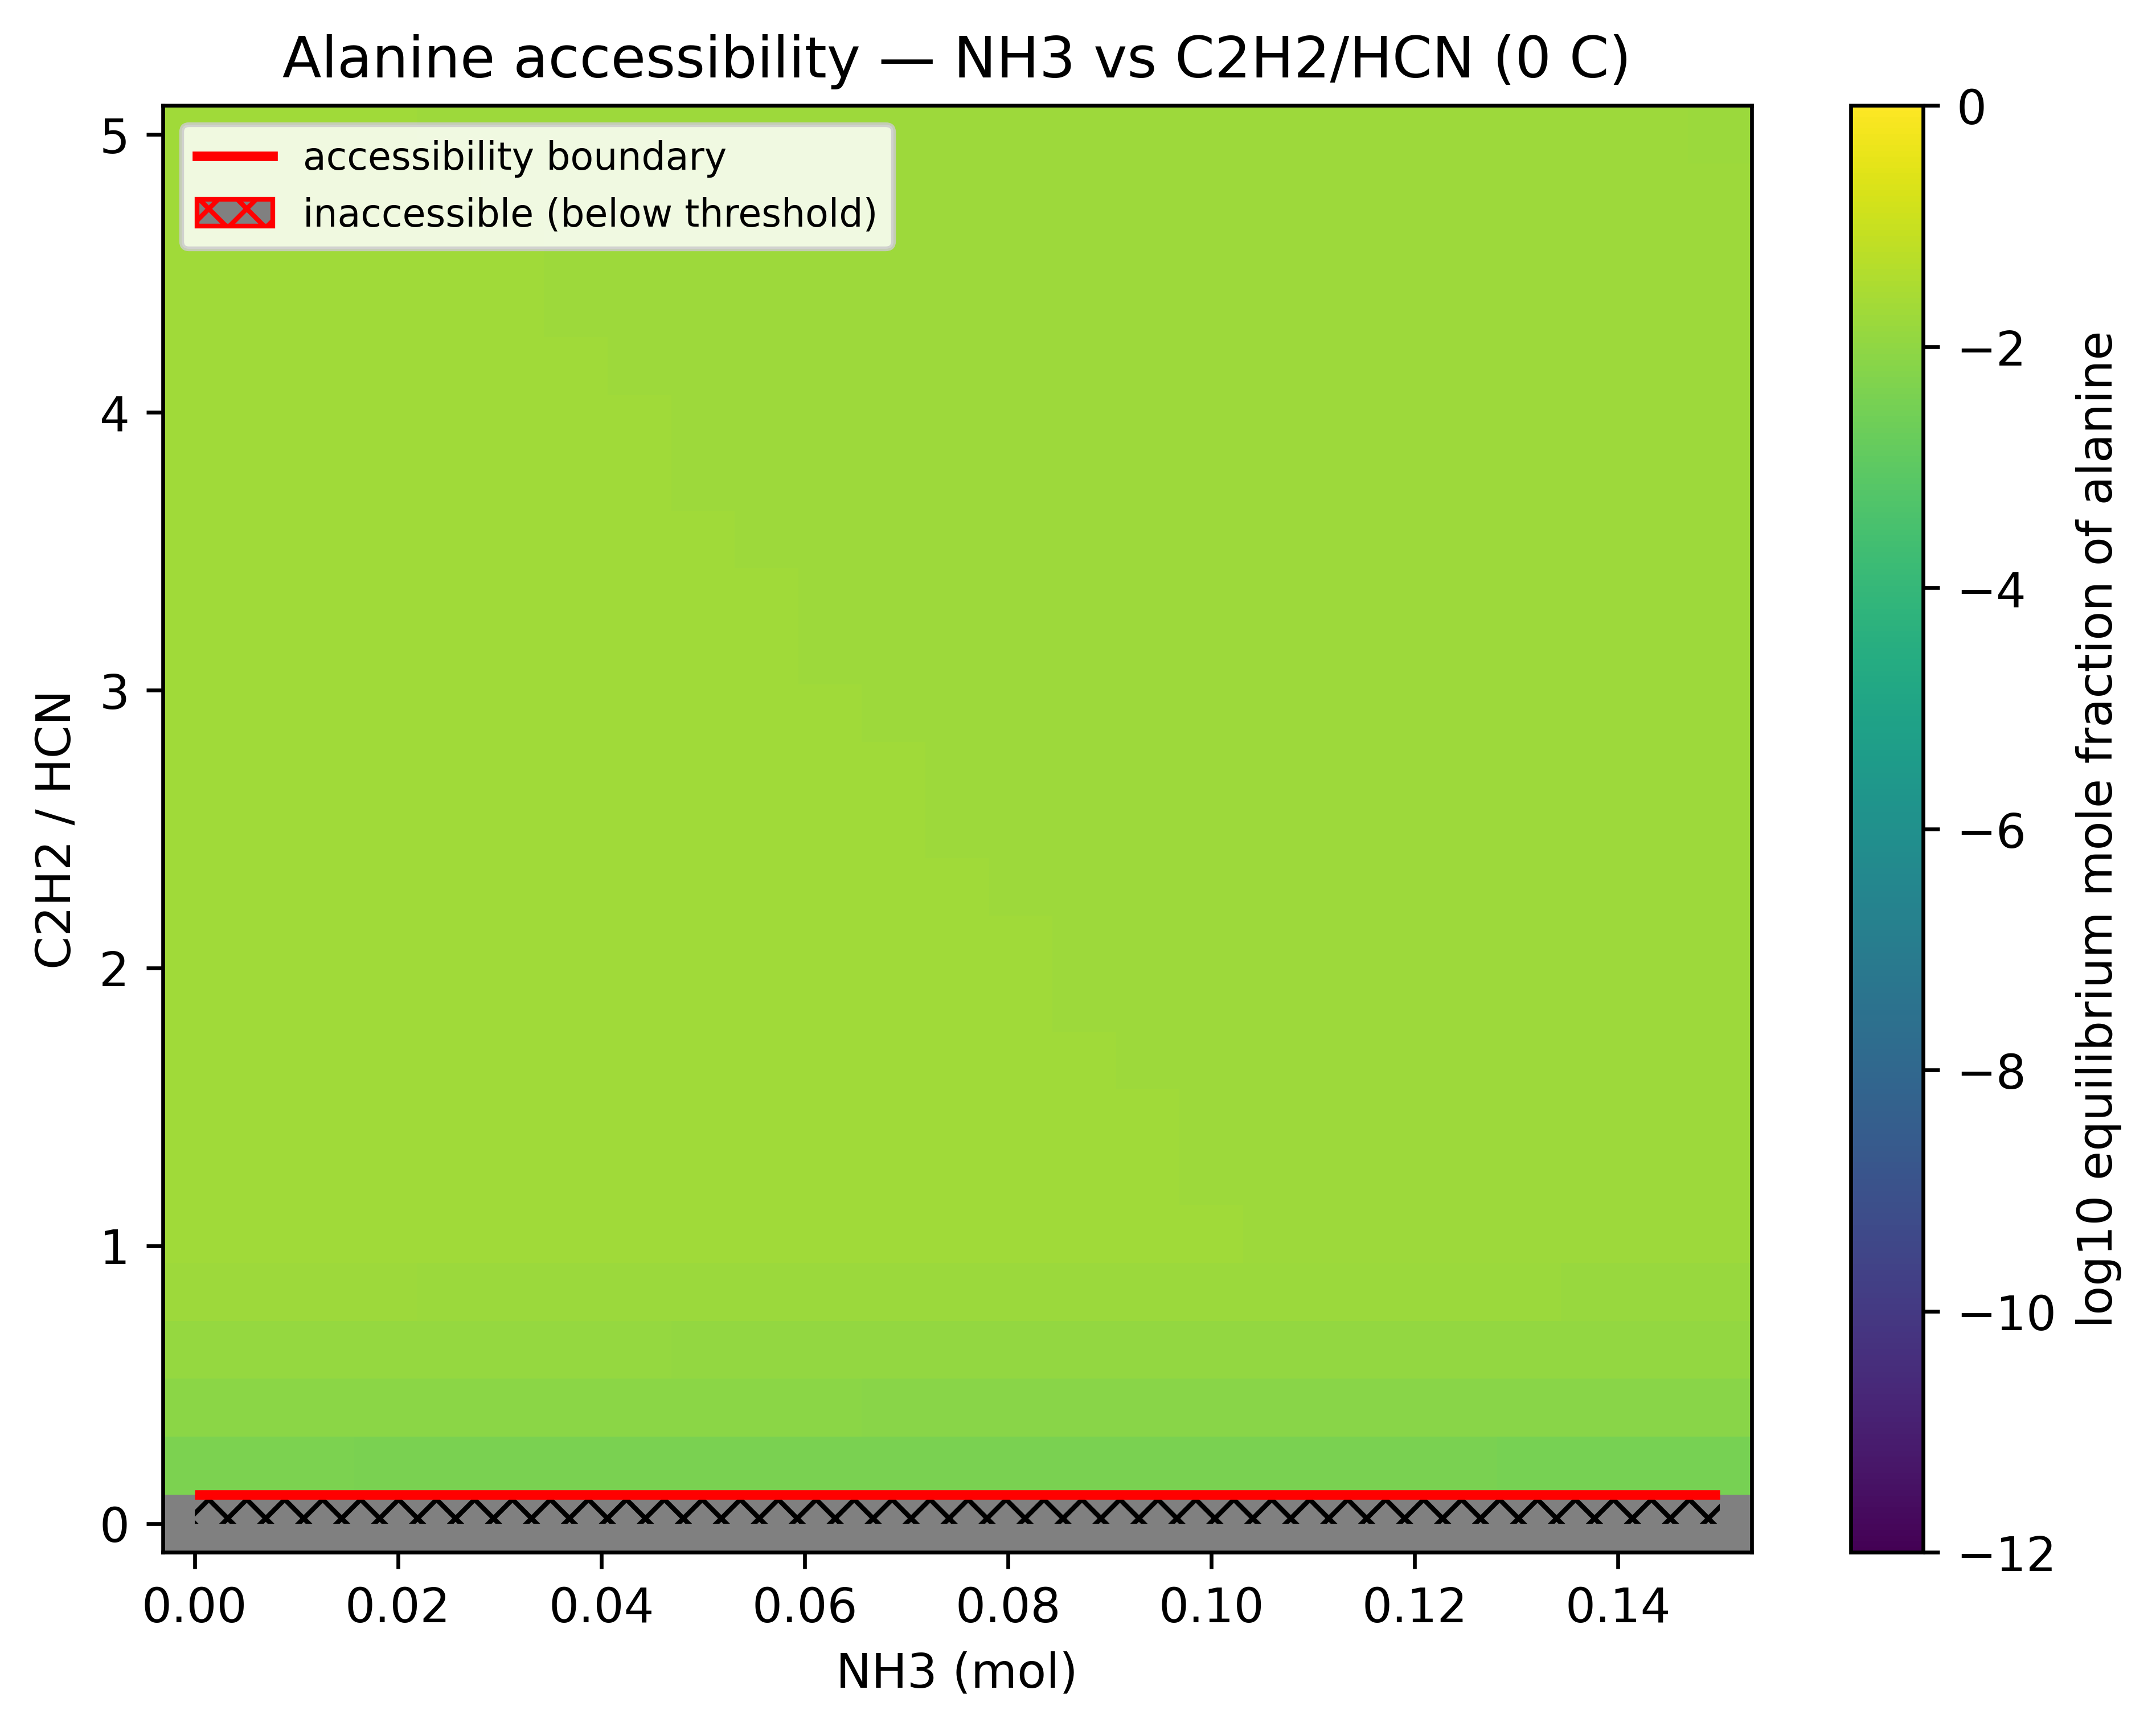

In [7]:
from __future__ import annotations

def show_png(path: Path, title: str | None = None, width: int = 760) -> None:
    """Display a PNG if it exists, otherwise show a clear missing-file note."""
    if title:
        display(Markdown(f"### {title}"))
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        display(Markdown(f"**Missing expected figure:** `{path}`"))


show_png(FIGURES_DIR / "inventory_landscape.png", "Inventory landscape — thresholded/fixed scale")


### Inventory landscape — autoscaled

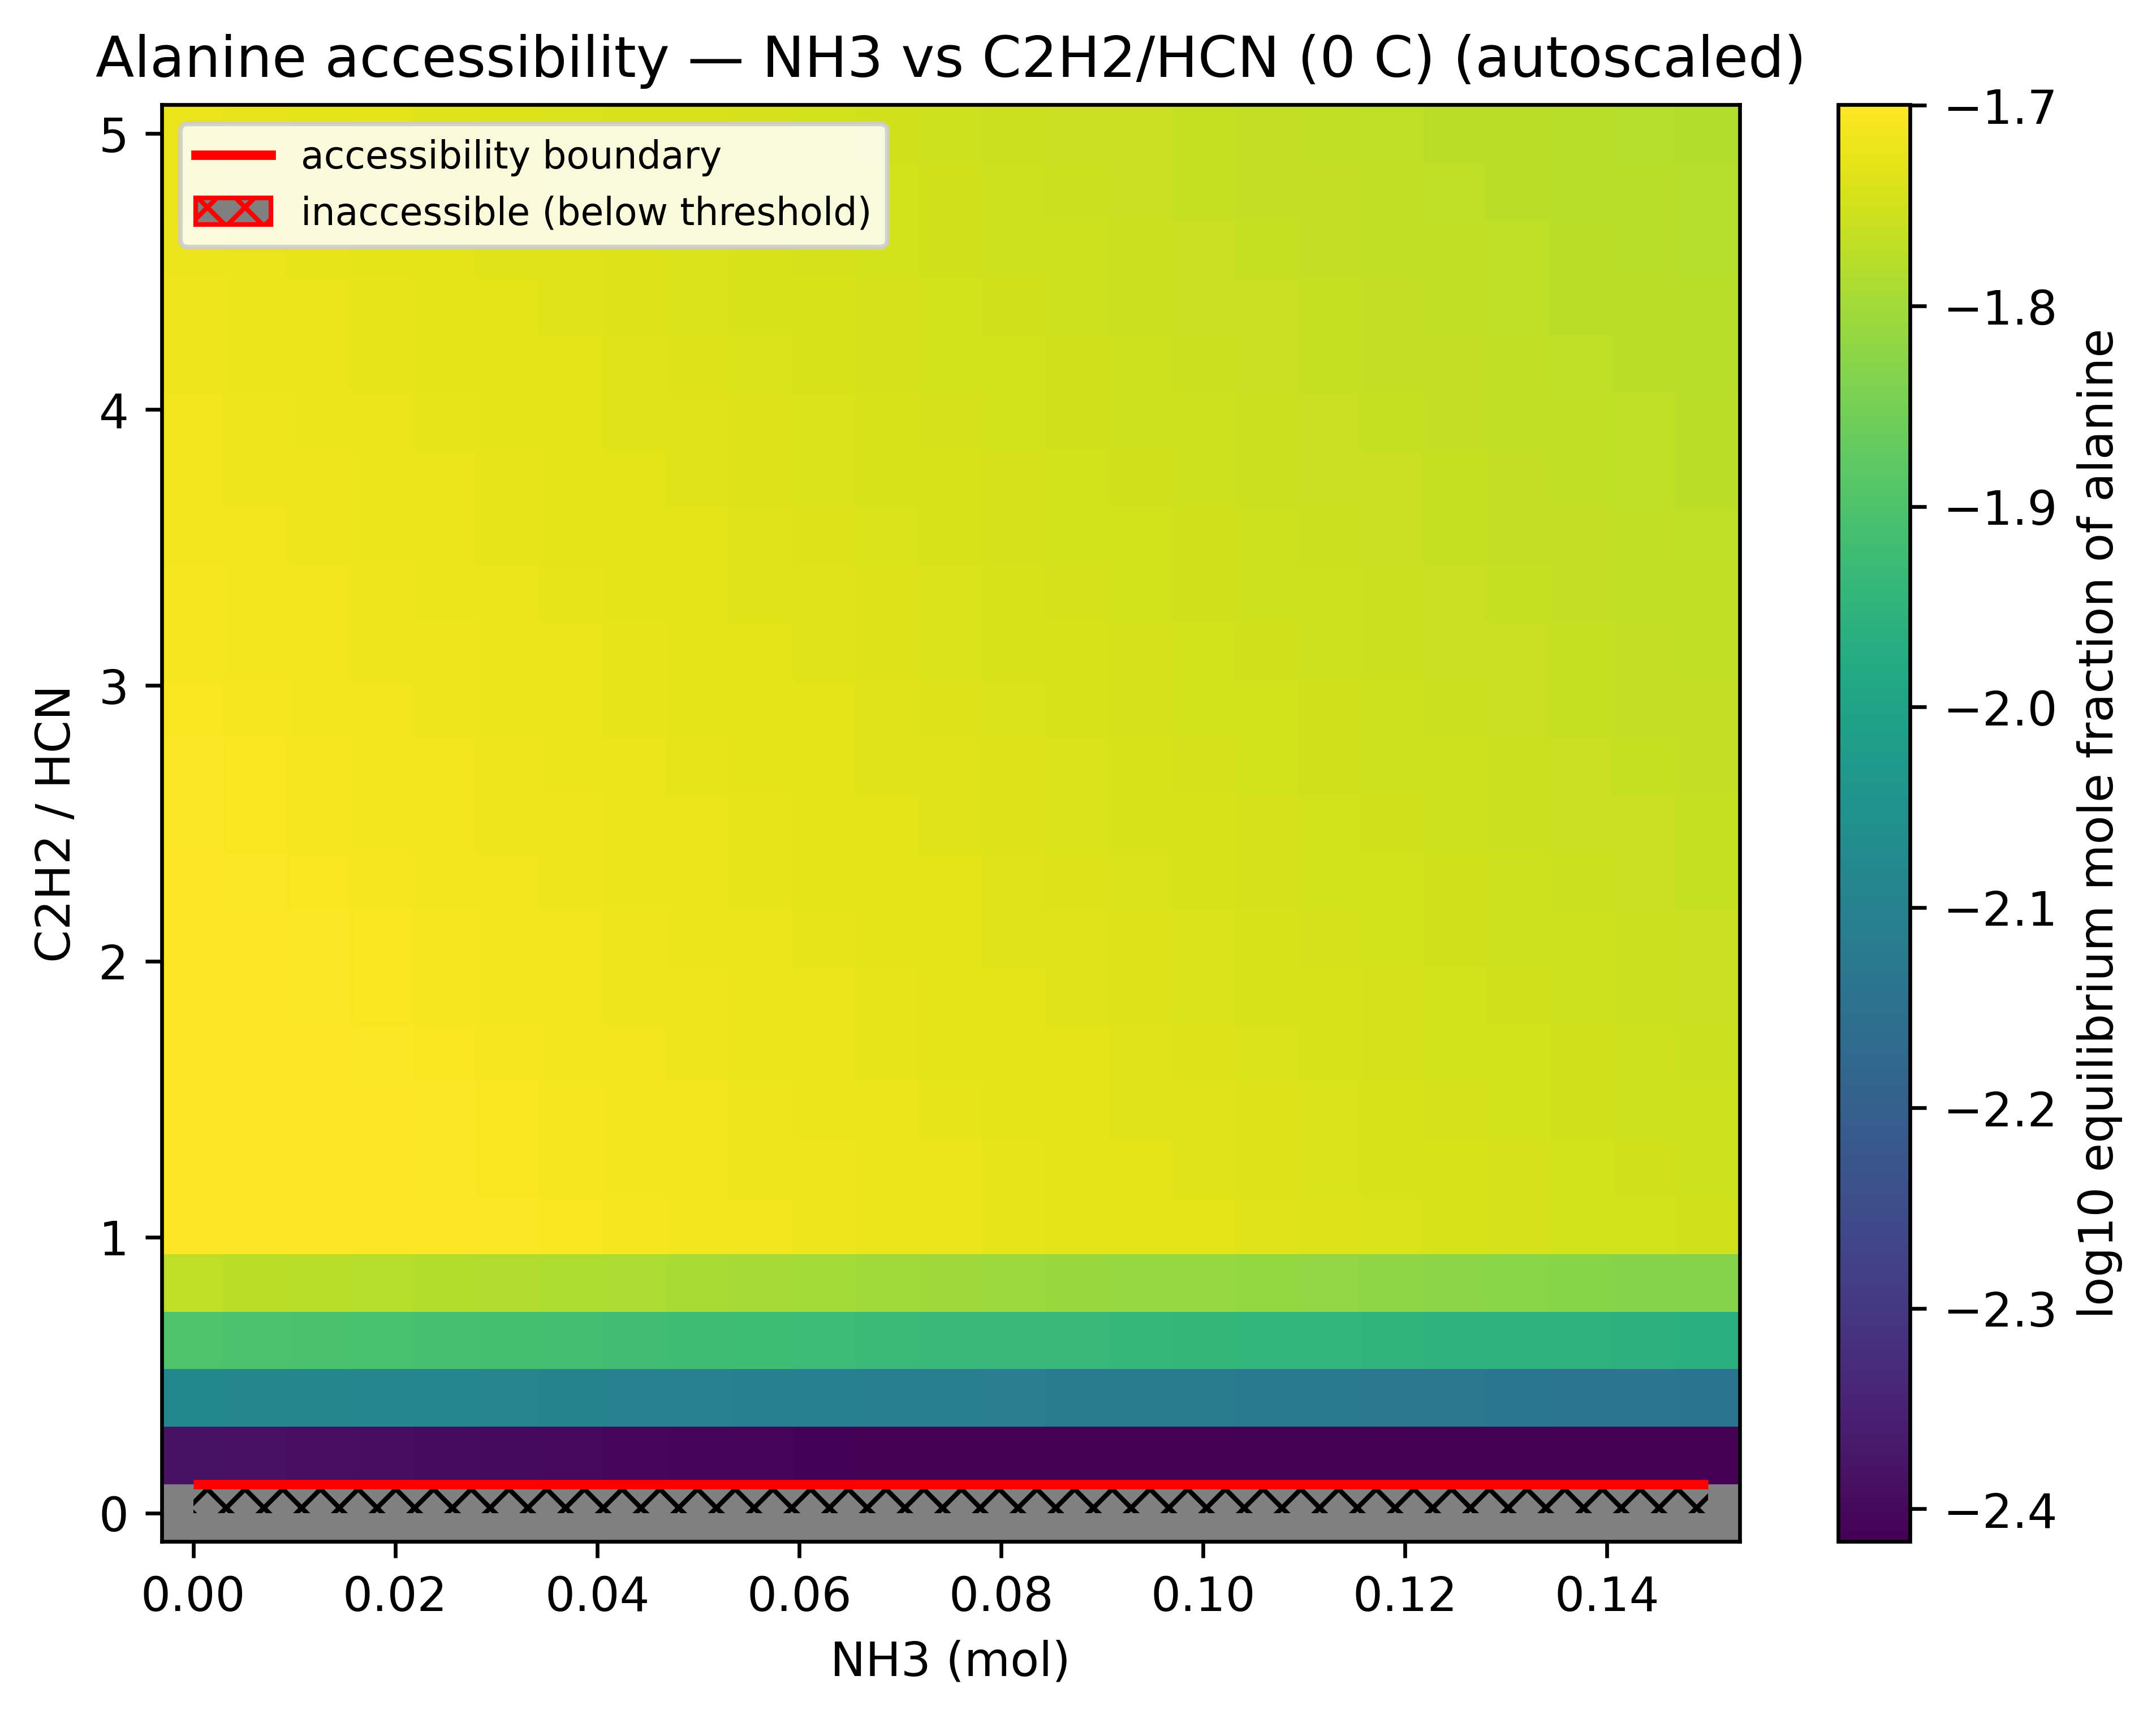

In [8]:
show_png(FIGURES_DIR / "inventory_landscape_autoscaled.png", "Inventory landscape — autoscaled")


In [9]:
# Numerical interpretation of the inventory landscape.
inv = case_summary[case_summary["substudy_id"] == "inventory_landscape"].copy()

if not inv.empty:
    inv_metrics = {
        "cases": len(inv),
        "accessible_cases": int(inv["formed_bool"].sum()),
        "accessible_fraction": float(inv["formed_bool"].mean()),
        "min_NH3_mol_for_accessibility": inv.loc[inv["formed_bool"], "NH3_mol"].min(),
        "min_C2H2_over_HCN_for_accessibility": inv.loc[inv["formed_bool"], "C2H2_over_HCN"].min(),
        "max_X_eq": inv["X_eq"].max(),
    }
    display(pd.Series(inv_metrics, name="inventory_landscape_metrics"))

    # Show the below-threshold edge cases, if any.
    below = inv[~inv["formed_bool"]].copy()
    below_cols = [
        "case_id",
        "NH3_mol",
        "HCN_mol",
        "C2H2_mol",
        "C2H2_over_HCN",
        "X_eq",
        "formation_call",
    ]
    below_cols = [col for col in below_cols if col in below.columns]
    display(below[below_cols].head(10))


cases                                  625.000000
accessible_cases                       600.000000
accessible_fraction                      0.960000
min_NH3_mol_for_accessibility            0.000000
min_C2H2_over_HCN_for_accessibility      0.208333
max_X_eq                                 0.020391
Name: inventory_landscape_metrics, dtype: float64

,case_id,NH3_mol,HCN_mol,C2H2_mol,C2H2_over_HCN,X_eq,formation_call
11,ALA_INV_000001,0.00000,0.02,0.0,0.0,0.0,below_threshold
36,ALA_INV_000026,0.00625,0.02,0.0,0.0,0.0,below_threshold
61,ALA_INV_000051,0.01250,0.02,0.0,0.0,0.0,below_threshold
86,ALA_INV_000076,0.01875,0.02,0.0,0.0,0.0,below_threshold
111,ALA_INV_000101,0.02500,0.02,0.0,0.0,0.0,below_threshold
136,ALA_INV_000126,0.03125,0.02,0.0,0.0,0.0,below_threshold
161,ALA_INV_000151,0.03750,0.02,0.0,0.0,0.0,below_threshold
186,ALA_INV_000176,0.04375,0.02,0.0,0.0,0.0,below_threshold
211,ALA_INV_000201,0.05000,0.02,0.0,0.0,0.0,below_threshold
236,ALA_INV_000226,0.05625,0.02,0.0,0.0,0.0,below_threshold


The key alanine interpretation is straightforward:

- alanine is accessible across most of the inventory grid,
- below-threshold cases occur at the low-acetylene edge of the design,
- NH3 is not acting as a narrow on/off gate in this specific MVP because the model allows NH3 to be present in the phase even when its initial amount is zero,
- the strongest inventory control is the availability of the carbon feedstock needed to satisfy alanine stoichiometry.

That is exactly the kind of distinction sensitivity landscapes are designed to reveal. The result is not just “alanine accessible.” It is more specifically: **alanine accessibility is robust across much of the tested inventory space, with the expected carbon-feedstock limitation at the C2H2-poor edge.**


## 8 — Reading ΔG sensitivity plots

The ΔG sweep asks:

> If alanine’s Gibbs free energy is shifted up or down, does the accessibility verdict change?

The x-axis is the exact Gibbs offset applied to the target variant:

- negative ΔG offset → target made more thermodynamically favorable,
- positive ΔG offset → target made less thermodynamically favorable.

The y-axis is `log10_X_eq`. The horizontal threshold line marks the accessibility cutoff.

How to read the pattern:

| Pattern | Interpretation |
|---|---|
| Always above threshold | Thermochemically robust across sampled offsets. |
| Crosses threshold near 0 kJ/mol | The result is fragile to plausible thermochemical uncertainty. |
| Only accessible at very negative offsets | The target may need unrealistically favorable thermochemistry. |
| Always below threshold | Not accessible under the tested fixed inventory. |

For alanine, a flat or always-above-threshold line means the accessibility call is not delicately controlled by small-to-large shifts in the target Gibbs free energy.


### ΔG sweep — fixed inventory

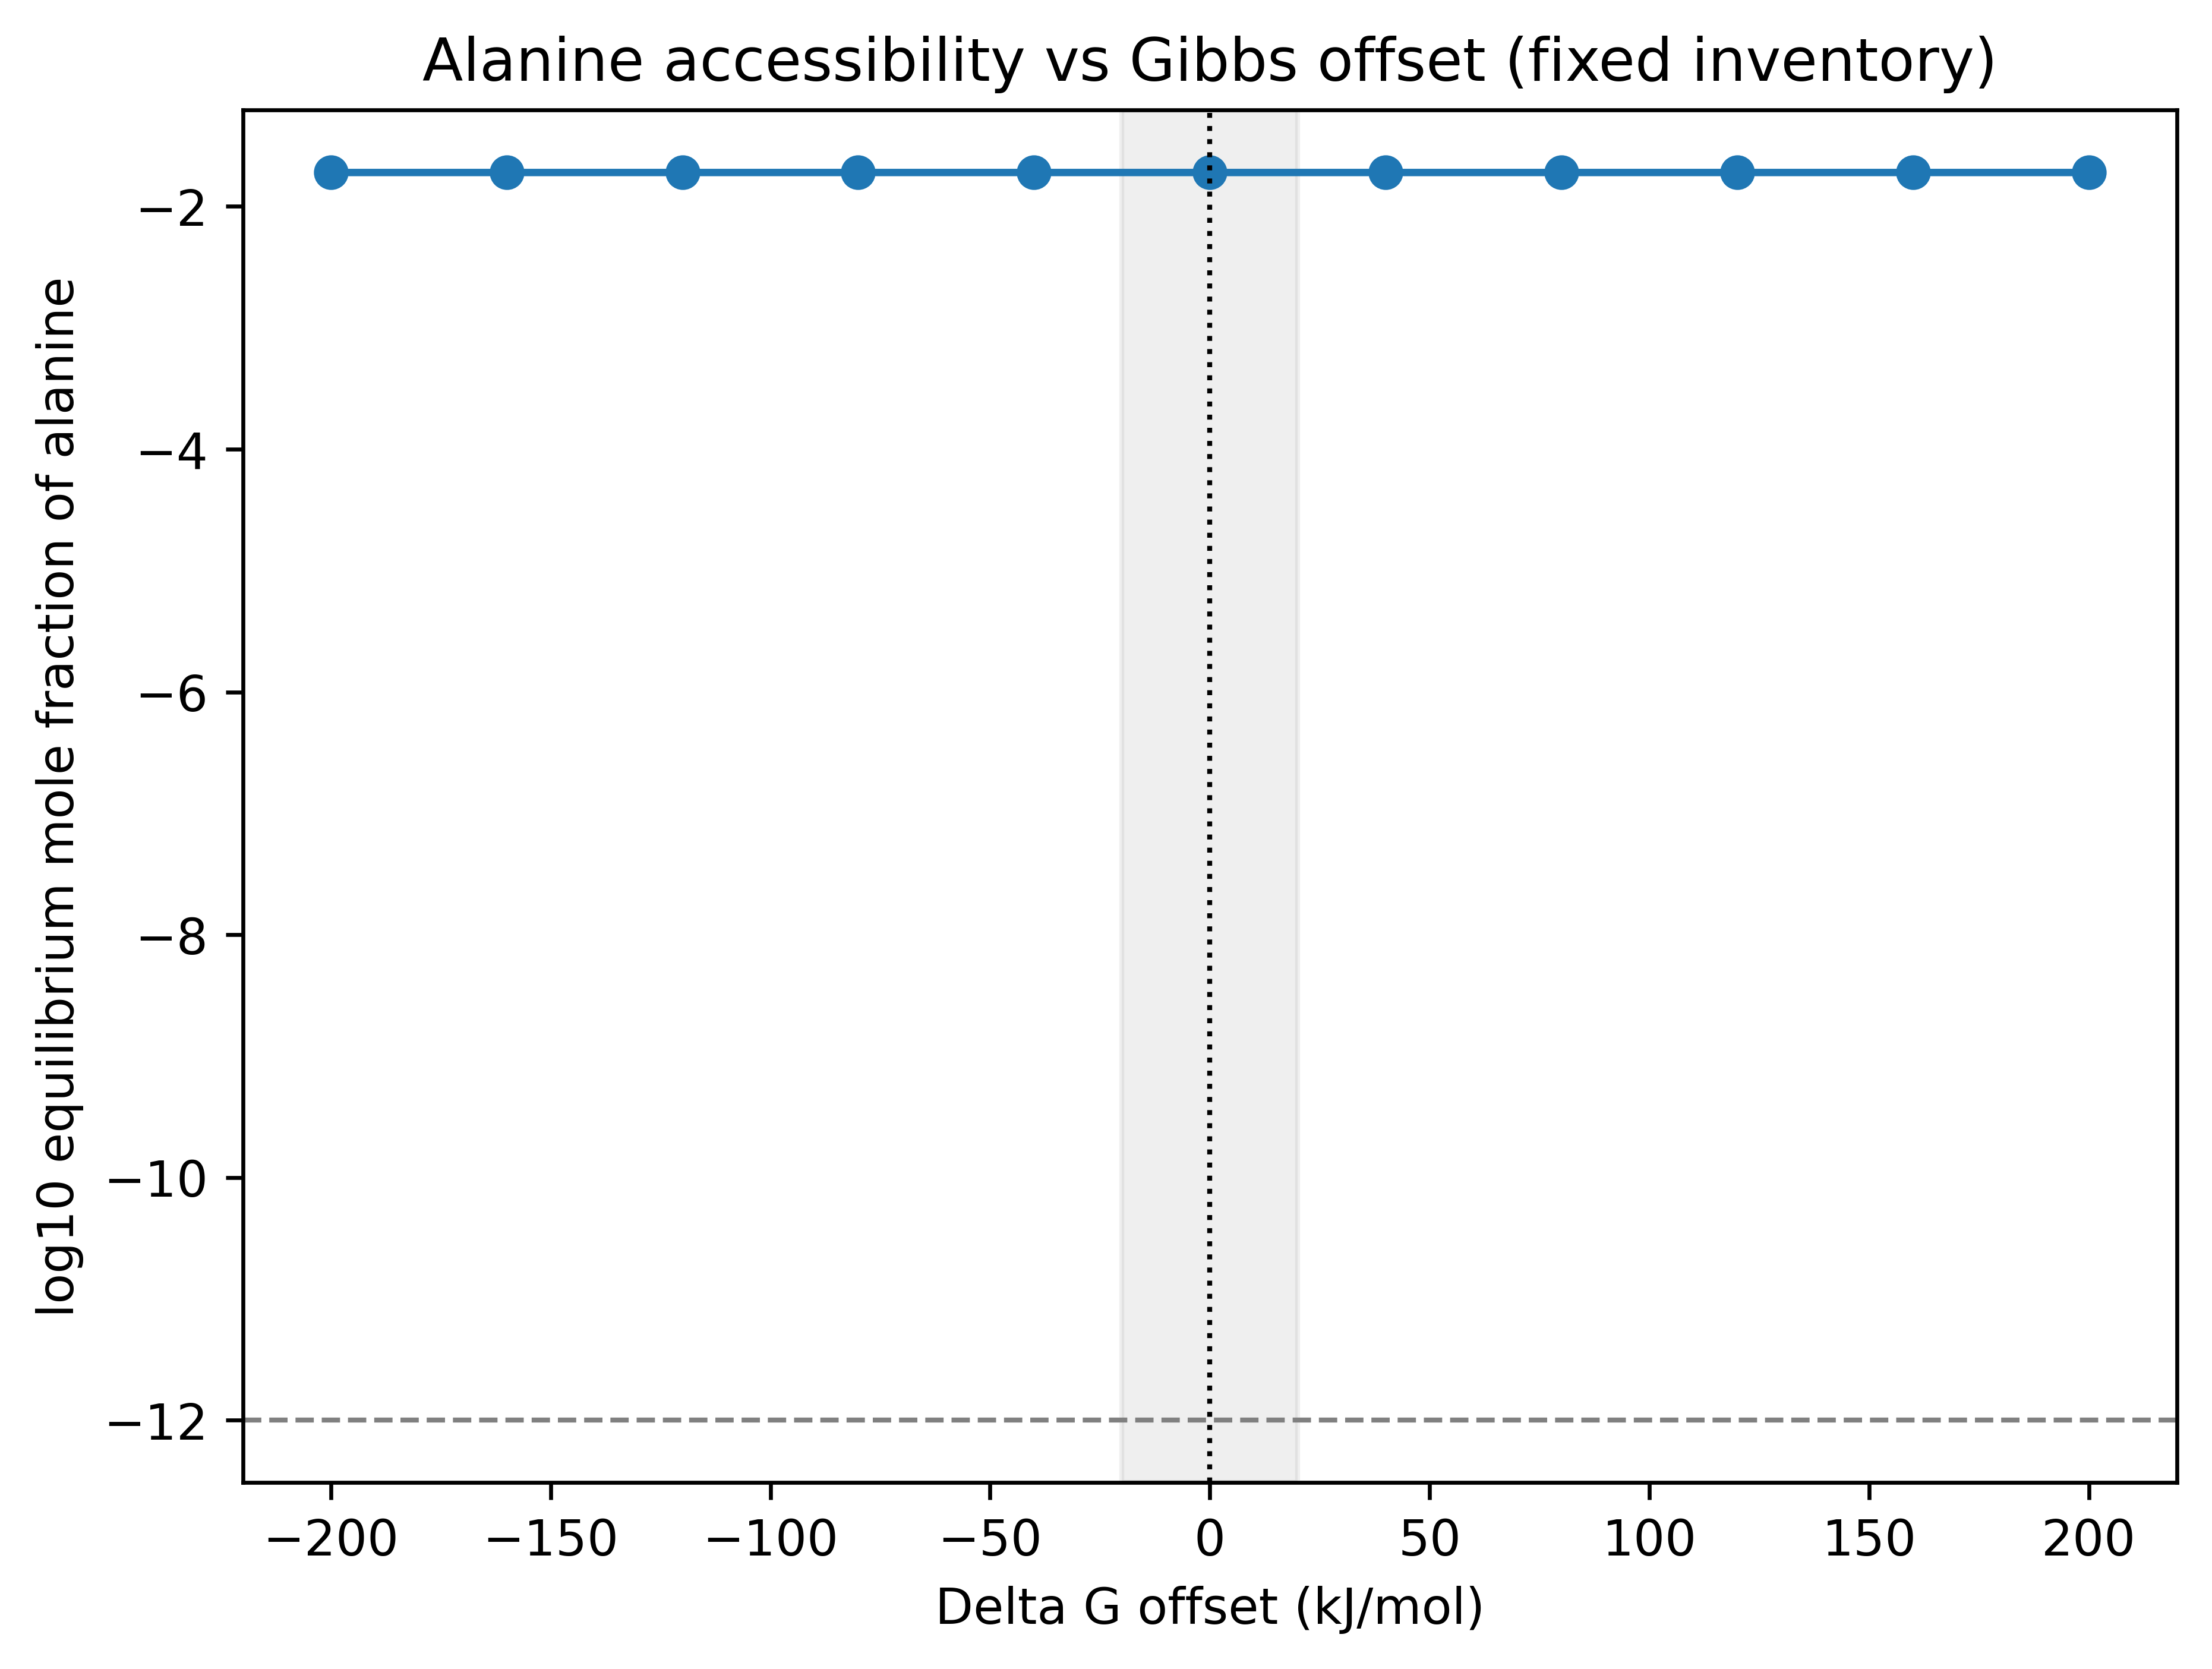

In [10]:
show_png(FIGURES_DIR / "deltaG_sweep.png", "ΔG sweep — fixed inventory")


In [11]:
dg = case_summary[case_summary["substudy_id"] == "deltaG_sweep"].copy()

if not dg.empty:
    dg_cols = [
        "case_id",
        "target_variant",
        "deltaG_offset_kJ_mol",
        "X_eq",
        "log10_X_eq",
        "formed_bool",
        "formation_call",
    ]
    dg_cols = [col for col in dg_cols if col in dg.columns]
    display(dg[dg_cols].sort_values("deltaG_offset_kJ_mol"))

    zero_row = dg.loc[dg["deltaG_offset_kJ_mol"].abs().idxmin()]
    dg_metrics = {
        "offset_min_kJ_mol": dg["deltaG_offset_kJ_mol"].min(),
        "offset_max_kJ_mol": dg["deltaG_offset_kJ_mol"].max(),
        "accessible_at_all_sampled_offsets": bool(dg["formed_bool"].all()),
        "X_eq_nearest_zero_offset": zero_row["X_eq"],
        "min_X_eq_across_offsets": dg["X_eq"].min(),
        "max_X_eq_across_offsets": dg["X_eq"].max(),
    }
    display(pd.Series(dg_metrics, name="deltaG_sweep_metrics"))


,case_id,target_variant,deltaG_offset_kJ_mol,X_eq,log10_X_eq,formed_bool,formation_call
0,ALA_DG_000001,Alanine__dG_m200(aq),-200.0,0.019011,-1.720986,True,significant
1,ALA_DG_000002,Alanine__dG_m160(aq),-160.0,0.019011,-1.720986,True,significant
2,ALA_DG_000003,Alanine__dG_m120(aq),-120.0,0.019011,-1.720986,True,significant
3,ALA_DG_000004,Alanine__dG_m080(aq),-80.0,0.019011,-1.720986,True,significant
4,ALA_DG_000005,Alanine__dG_m040(aq),-40.0,0.019011,-1.720986,True,significant
5,ALA_DG_000006,Alanine__dG_000(aq),0.0,0.019011,-1.720986,True,significant
6,ALA_DG_000007,Alanine__dG_p040(aq),40.0,0.019011,-1.720986,True,significant
7,ALA_DG_000008,Alanine__dG_p080(aq),80.0,0.019011,-1.720986,True,significant
8,ALA_DG_000009,Alanine__dG_p120(aq),120.0,0.019011,-1.720986,True,significant
9,ALA_DG_000010,Alanine__dG_p160(aq),160.0,0.019011,-1.720986,True,significant


offset_min_kJ_mol                      -200.0
offset_max_kJ_mol                       200.0
accessible_at_all_sampled_offsets        True
X_eq_nearest_zero_offset             0.019011
min_X_eq_across_offsets              0.019011
max_X_eq_across_offsets              0.019011
Name: deltaG_sweep_metrics, dtype: object

The alanine ΔG sweep is intentionally severe: it spans a wide range of target Gibbs offsets. If alanine remains accessible across that full range, then the yes/no accessibility call is not dependent on a finely tuned alanine free energy.

This is scientifically useful because estimated thermochemistry often carries uncertainty. A robust ΔG sweep says:

> The qualitative accessibility result is stable even if the target’s assumed Gibbs free energy is shifted.

That does not mean the exact `X_eq` value is universal. It means the threshold-level verdict is not fragile within the tested range.


## 9 — Reading the NH3 × ΔG landscape and forming the final verdict

The NH3 × ΔG landscape combines inventory and thermochemical sensitivity.

It asks:

> Does the ΔG robustness of alanine depend on how much NH3 is initially available?

This is useful because inventory uncertainty and thermochemical uncertainty are not always independent. A target might be robust at one feedstock level but fragile near a limiting edge of the design.

For the alanine MVP:

- x-axis: initial `NH3_mol`,
- y-axis: alanine `deltaG_offset_kJ_mol`,
- color: `log10_X_eq`,
- boundary/hatching: below-threshold region, if present.

Again, use the fixed-scale plot for the threshold verdict and the autoscaled plot for visual gradients.


### NH3 × ΔG landscape — thresholded/fixed scale

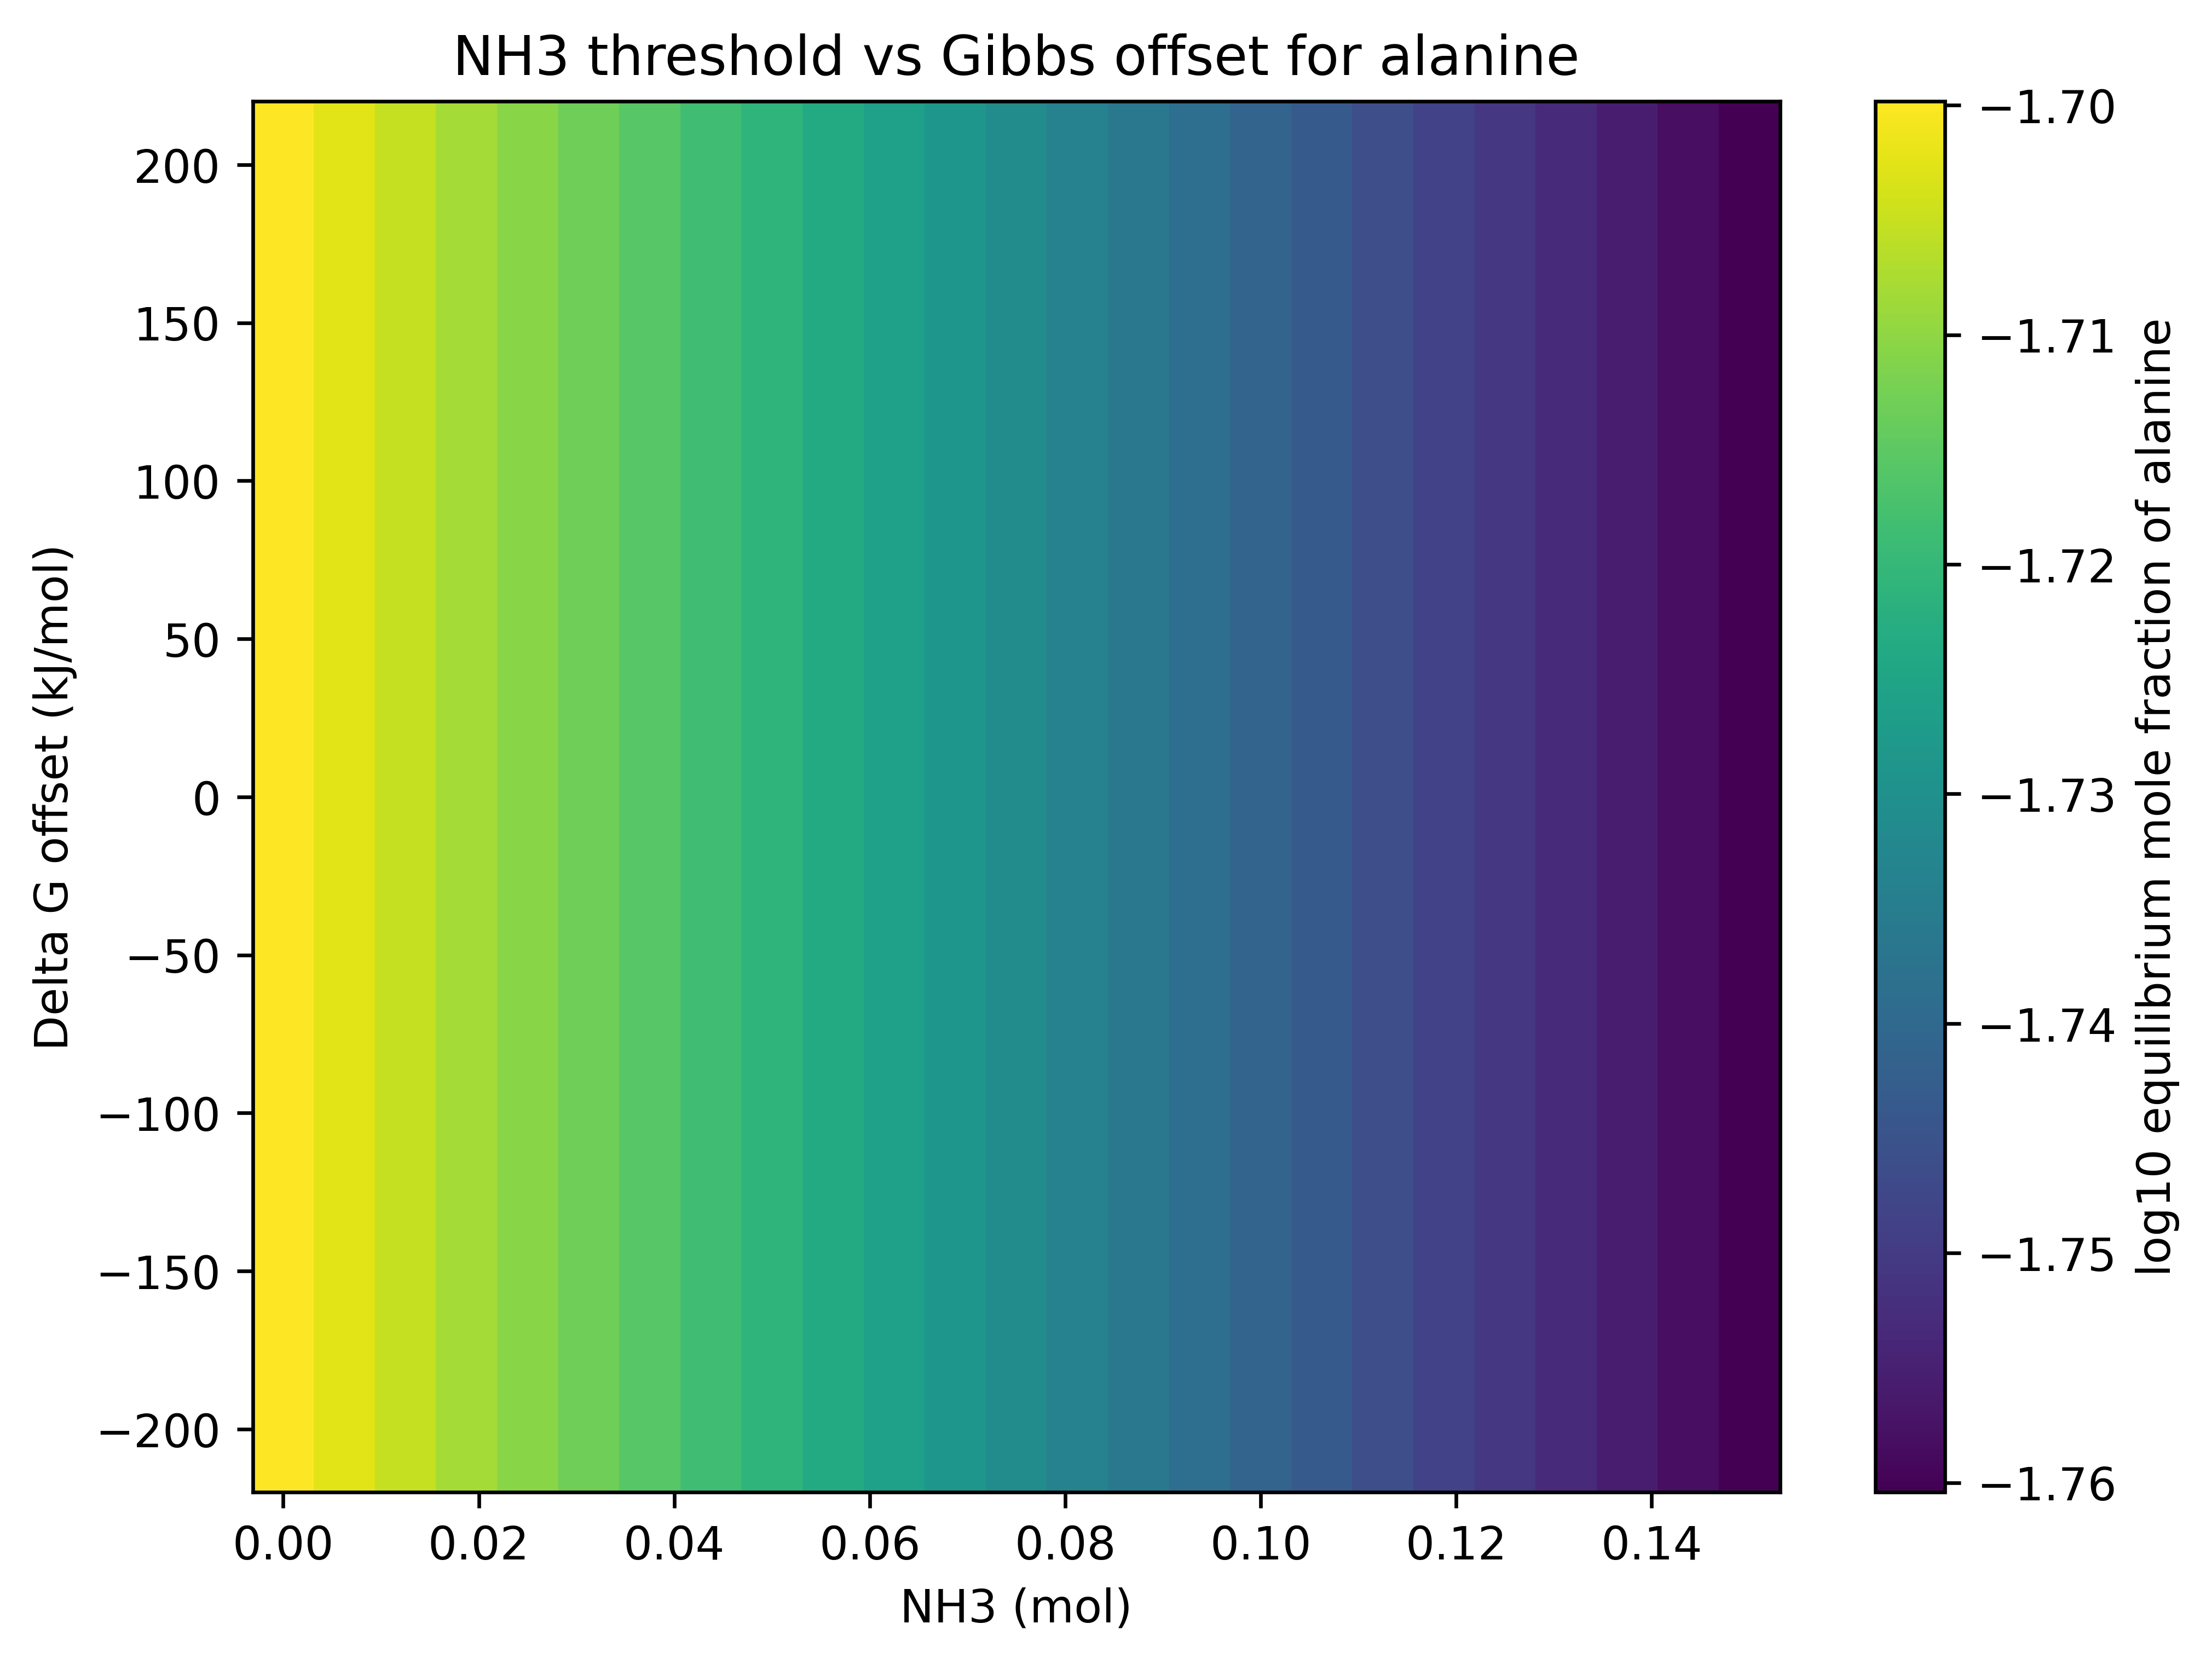

### NH3 × ΔG landscape — autoscaled

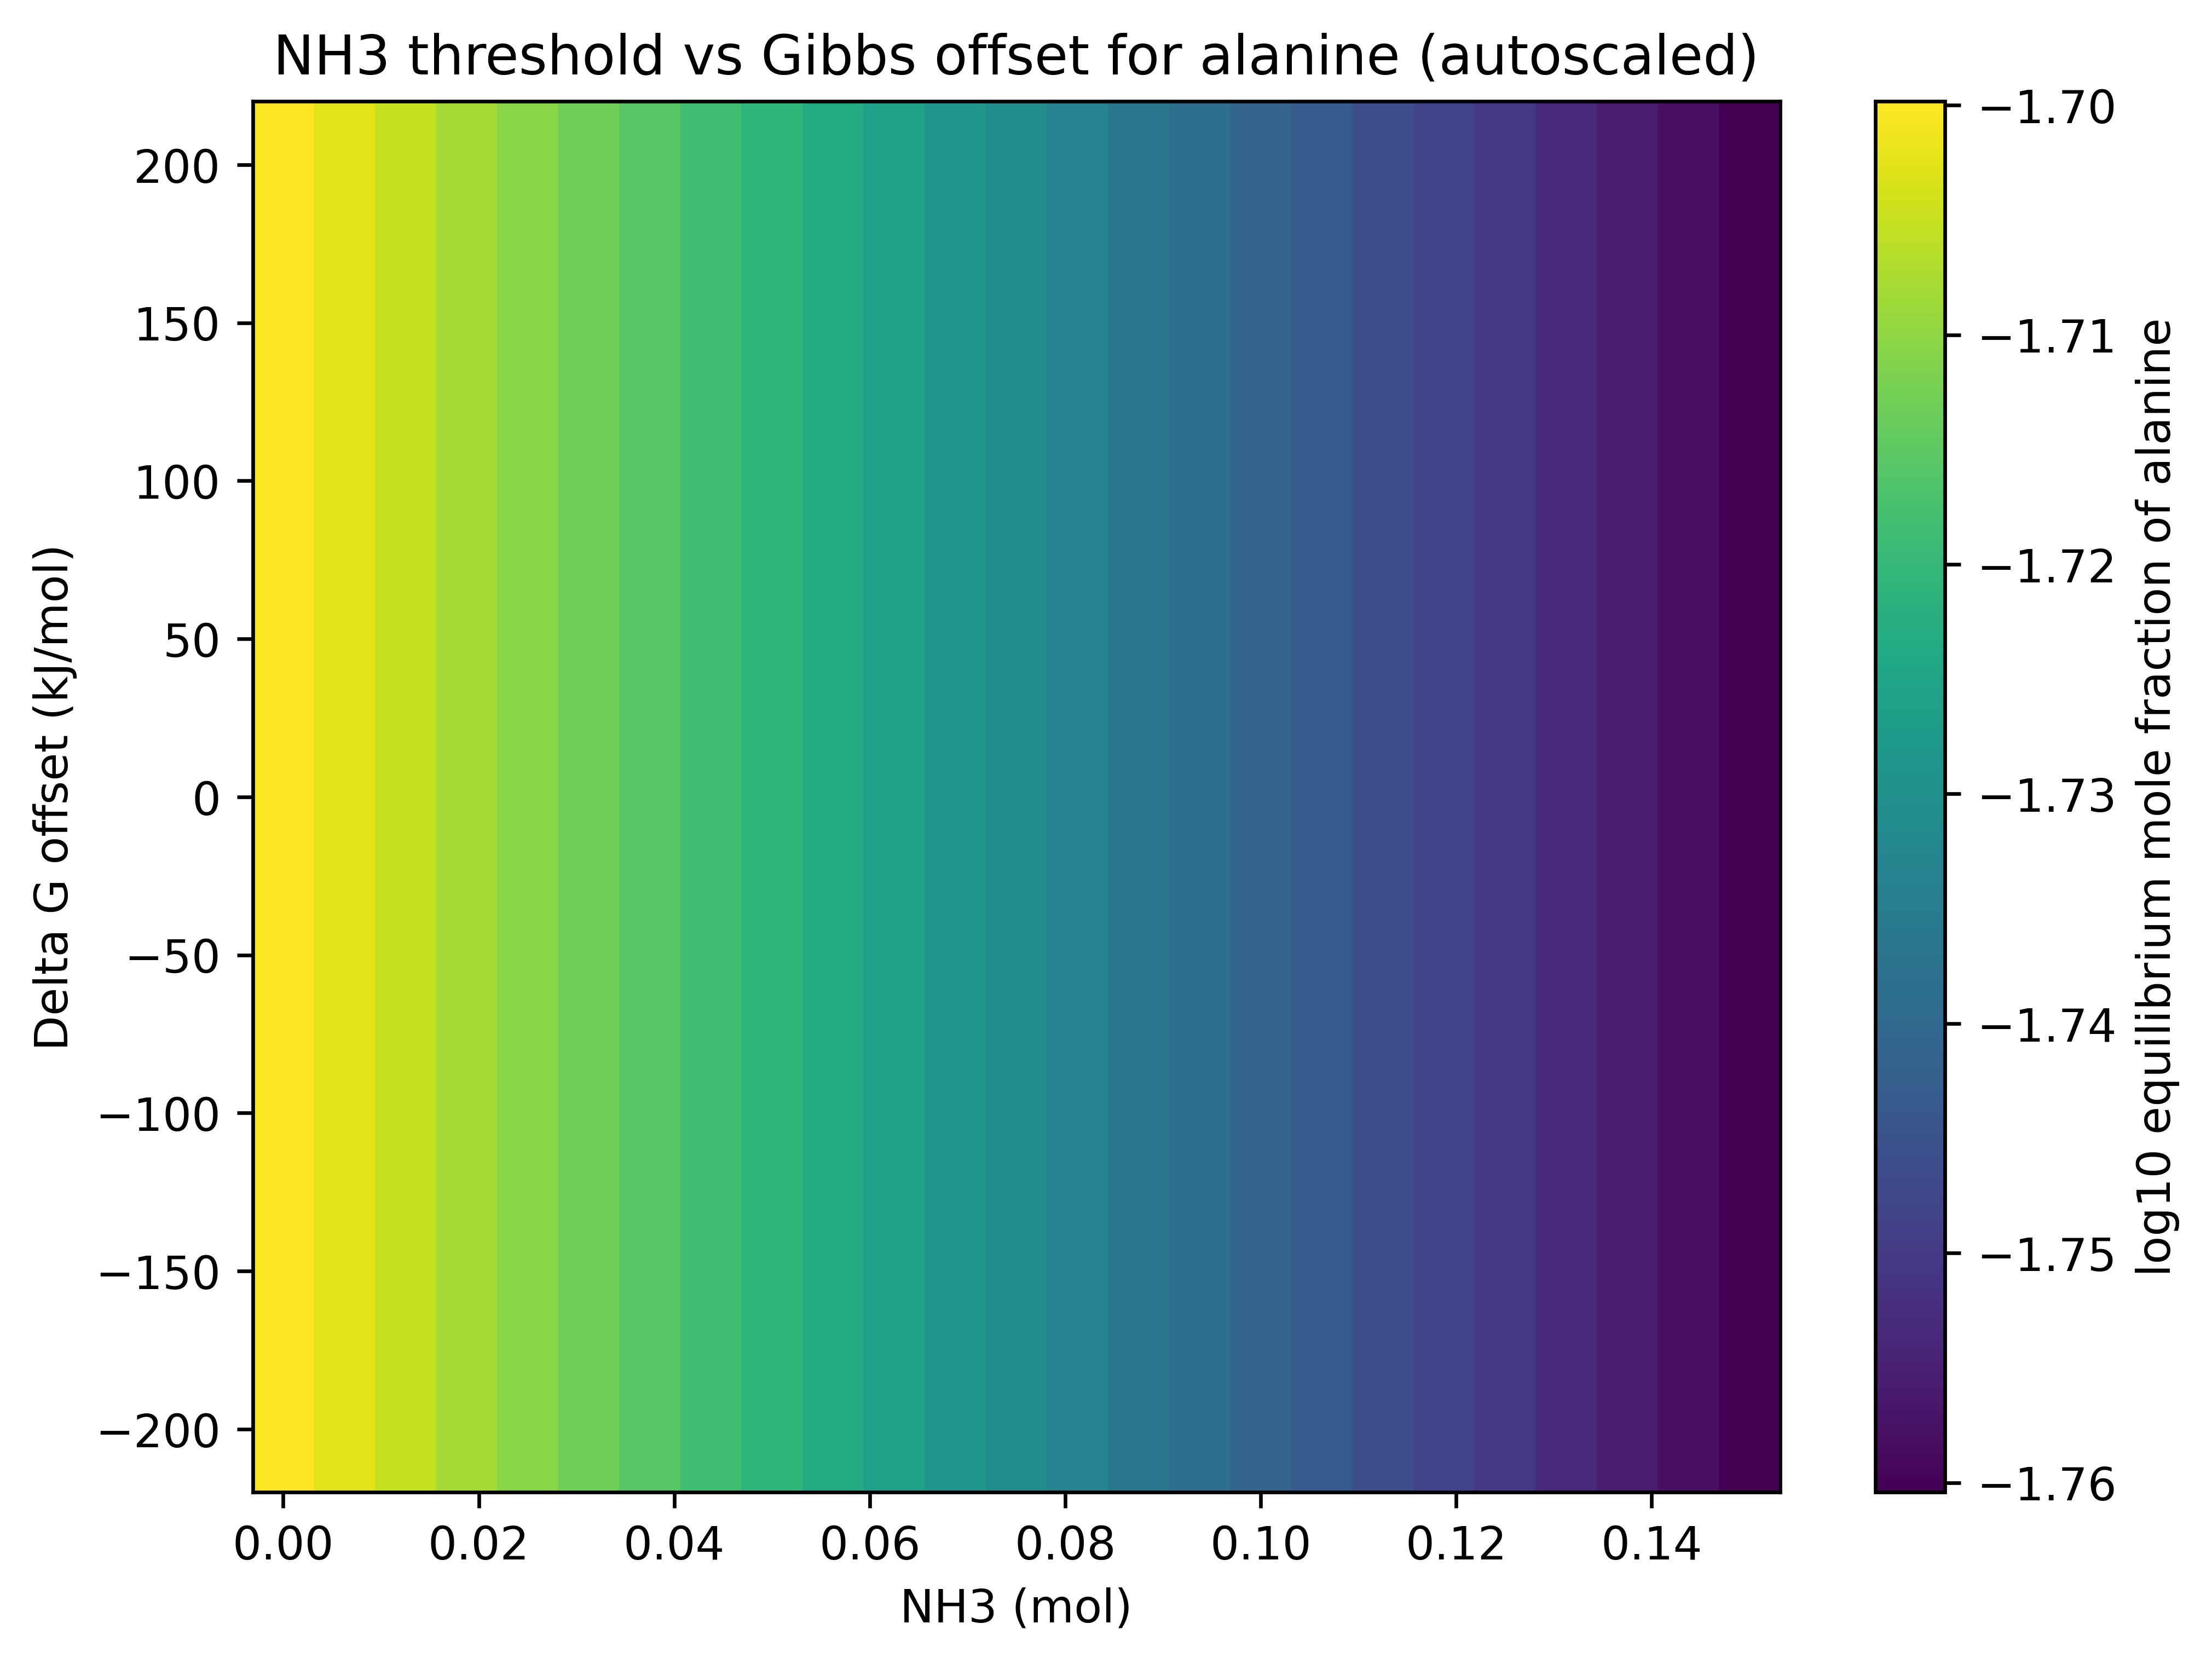

In [12]:
show_png(FIGURES_DIR / "nh3_deltaG_landscape.png", "NH3 × ΔG landscape — thresholded/fixed scale")
show_png(FIGURES_DIR / "nh3_deltaG_landscape_autoscaled.png", "NH3 × ΔG landscape — autoscaled")


In [13]:
nh3dg = case_summary[case_summary["substudy_id"] == "nh3_deltaG_landscape"].copy()

if not nh3dg.empty:
    nh3dg_metrics = {
        "cases": len(nh3dg),
        "accessible_cases": int(nh3dg["formed_bool"].sum()),
        "accessible_fraction": float(nh3dg["formed_bool"].mean()),
        "NH3_min_mol": nh3dg["NH3_mol"].min(),
        "NH3_max_mol": nh3dg["NH3_mol"].max(),
        "deltaG_min_kJ_mol": nh3dg["deltaG_offset_kJ_mol"].min(),
        "deltaG_max_kJ_mol": nh3dg["deltaG_offset_kJ_mol"].max(),
        "min_X_eq": nh3dg["X_eq"].min(),
        "median_X_eq": nh3dg["X_eq"].median(),
        "max_X_eq": nh3dg["X_eq"].max(),
    }
    display(pd.Series(nh3dg_metrics, name="nh3_deltaG_landscape_metrics"))

    # Accessibility fraction by ΔG offset: a compact way to see whether any offset breaks the call.
    offset_summary = (
        nh3dg.groupby("deltaG_offset_kJ_mol")
        .agg(
            cases=("case_id", "count"),
            accessible_fraction=("formed_bool", "mean"),
            min_X_eq=("X_eq", "min"),
            max_X_eq=("X_eq", "max"),
        )
        .reset_index()
    )
    display(offset_summary)


cases                  275.000000
accessible_cases       275.000000
accessible_fraction      1.000000
NH3_min_mol              0.000000
NH3_max_mol              0.150000
deltaG_min_kJ_mol     -200.000000
deltaG_max_kJ_mol      200.000000
min_X_eq                 0.017361
median_X_eq              0.018570
max_X_eq                 0.019960
Name: nh3_deltaG_landscape_metrics, dtype: float64

,deltaG_offset_kJ_mol,cases,accessible_fraction,min_X_eq,max_X_eq
0,-200.0,25,1.0,0.017361,0.01996
1,-160.0,25,1.0,0.017361,0.01996
2,-120.0,25,1.0,0.017361,0.01996
3,-80.0,25,1.0,0.017361,0.01996
4,-40.0,25,1.0,0.017361,0.01996
5,0.0,25,1.0,0.017361,0.01996
6,40.0,25,1.0,0.017361,0.01996
7,80.0,25,1.0,0.017361,0.01996
8,120.0,25,1.0,0.017361,0.01996
9,160.0,25,1.0,0.017361,0.01996


### Worked alanine MVP verdict

The practical verdict is stronger than a single yes/no result.

For the bundled alanine MVP, the outputs support this interpretation:

> Under this model setup, alanine is equilibrium-accessible across most of the tested starting-inventory space and remains accessible across the tested ΔG-offset range. The main below-threshold behavior appears at the low-acetylene edge of the inventory landscape, consistent with a stoichiometric/feedstock limitation rather than a delicate dependence on alanine’s exact Gibbs free energy.

In plain language:

- the alanine accessibility call is **mostly robust**,
- the model is more constrained by inventory/elemental balance than by the sampled alanine ΔG shifts,
- the sensitivity workflow adds value by showing which parts of the prediction are stable and which are gated by feedstock availability.

The careful scientific statement is:

> Alanine is robustly equilibrium-accessible within the tested alanine MVP design, subject to the assumptions of the single-product equilibrium model and the configured accessibility thresholds.

The careful caveat remains:

> This does not prove reaction kinetics, pathway feasibility, experimental yield, detectability, or formation in a real non-equilibrium system.


In [14]:
# Display the machine-generated run summary from the workflow.
summary_path = RESULTS_DIR / "sensitivity_run_summary.md"
if summary_path.exists():
    display(Markdown(summary_path.read_text()))
else:
    display(Markdown(f"Missing expected summary file: `{summary_path}`"))


# Sensitivity run summary — alanine_mvp

## Overview

- Total cases: 911
- Successful: 911
- Failed: 0 (failure rate 0.0%)
- Suspect element balance: 0
- Median runtime: 0.0011 s/case
- Max runtime: 0.0391 s
- Total runtime: 1.2 s

## Inventory landscape

- Cases: 625
- Accessible-area fraction: 0.960
- Min NH3 for accessibility: 0.0
- Min C2H2/HCN for accessibility: 0.2083333333333333
- Max X_eq: 0.0203908241291418 (case ALA_INV_000006)

## ΔG sweep

- Cases: 11
- X_eq at 0 kJ/mol: 0.0190114068441064
- Crossing offset (negative side): None kJ/mol
- Crossing offset (positive side): None kJ/mol
- Robust to ±20 kJ/mol: True
- Robust to ±40 kJ/mol: True

## NH3 × ΔG landscape

- Cases: 275
- NH3 threshold at 0 kJ/mol: 0.0
- NH3 threshold at min offset: 0.0
- NH3 threshold at max offset: 0.0
- Threshold shifts with offset: False


## Where to go next

Use this notebook when you want to learn interpretation without running anything.

Use the rest of the repository depending on your goal:

| Goal | Start here |
|---|---|
| Learn interpretation only | `notebooks/00_start_here_sensitivity_landscapes.ipynb` |
| Run the original single-scenario workflow | `notebooks/01_full_cantera_equilibrium_workflow_v4.ipynb` |
| Run or resume a sensitivity study from a notebook | `notebooks/02_sensitivity_landscape_workflow.ipynb` |
| Use the command line | `docs/SENSITIVITY_CLI.md` |
| Create a new study folder | `python scripts/new_study.py --id <study_id>` |
| Modify the alanine MVP design | `studies/alanine_mvp/study_config.yaml` |

A good end-user path is:

1. Read this notebook.
2. Open `studies/alanine_mvp/study_config.yaml` and connect each plot back to the sweep definitions.
3. Run `02_sensitivity_landscape_workflow.ipynb` only after you understand what the committed outputs mean.
4. Create a new study when you are ready to test your own target molecule.

The core habit is: **inspect the design matrix first, audit solver/balance status second, interpret tables third, and use plots as the visual summary.**
